# Packages import

In [1]:
import csv
import pandas as pd
import glob
import matplotlib.pyplot as plt
import os
import numpy as np
import seaborn as sns; sns.set_theme()
import math
from io import StringIO

C:\Users\USER\miniconda3\envs\chem\lib\site-packages\scipy\__init__.py:177: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
frames_per_ns = 20
work_dir_native = r"C:\Users\USER\OneDrive\Documents\work\Projects\Abl1 kinase Karpenko autoencoder model 1\abl_native"
work_dir_mutant = r"C:\Users\USER\OneDrive\Documents\work\Projects\Abl1 kinase Karpenko autoencoder model 1\abl_mutant"
save_dir = r"C:\Users\USER\OneDrive\Documents\work\Projects\Abl1 kinase Karpenko autoencoder model 1\abl_native\MD report test"
RU = False

# Energy analysis

##### Helper Functions

In [3]:
def get_energy_delta_csv(dat_file, mode="gb"):
    energy_lines = open(dat_file, 'r').readlines()
    
    if mode == "gb":
        line = "GENERALIZED BORN:\n"
    elif mode == "pb":
        line = "POISSON BOLTZMANN:\n"
    elif mode == "entropy":
        line = "NMODE entropy results\n"
    
    try:
        cm_index = energy_lines.index(line)
    except:
        print(os.path.basename(dat_file), ": " + line[:-1] + " NOT FOUND")
        return
    
    try:
        delta_index = energy_lines[cm_index:].index('DELTA Energy Terms\n')
    except:
        print(os.path.basename(dat_file), ": DELTA Energy Terms NOT FOUND")
        return
    
    delta_end_index = delta_index + energy_lines[delta_index:].index('\n')
    delta_string = ''.join(energy_lines[delta_index+1:delta_end_index])

    return StringIO(delta_string)

def mean_window(energy, window_size=11):
    size = energy.shape[0]
    res = np.zeros(shape=size)
    for i in range(0, size):
        bottom = max(i - window_size // 2, 0)
        upper = min(size, i + window_size - window_size // 2)
        res[i] = np.nanmean(energy[bottom:upper])
    return res

## Enthalpy

##### Helper Functions

In [4]:
def get_enthalpy_df(enthalpy_dir, enthalpy_threshold_frame):
    pd_enthalpy_dict = {'Name' : [], 'Enthalpy' : []}
    
    for enthalpy_file in glob.glob(enthalpy_dir + os.sep + '*.dat'):
        pd_enthalpy_dict['Name'].append(os.path.basename(enthalpy_file[:-4]))
        pd_enthalpy_dict['Enthalpy'].append(pd.read_csv(get_energy_delta_csv(enthalpy_file, mode="gb"))['DELTA TOTAL'].values)
        
    df_energy = pd.DataFrame(pd_enthalpy_dict)
    df_energy['Enthalpy_mean_std'] = df_energy['Enthalpy'].apply(lambda x: (x[enthalpy_threshold_frame:].mean(), x[enthalpy_threshold_frame:].std(ddof=1)))
    return df_energy

### Get enthalpy data

In [5]:
enthalpy_dir_native = work_dir_native + os.sep + 'enthalpy'
enthalpy_dir_mutant = work_dir_mutant + os.sep + 'enthalpy'
enthalpy_start, enthalpy_end, enthalpy_step = 2, 4000, 2

energy_mean_threshold = 51 #ns

#####

enthalpy_time = np.arange(enthalpy_start, enthalpy_end+1, enthalpy_step) / frames_per_ns
enthalpy_threshold_frame = (energy_mean_threshold * frames_per_ns - enthalpy_start) // enthalpy_step

df_energy = pd.merge(get_enthalpy_df(enthalpy_dir_native, enthalpy_threshold_frame), 
                     get_enthalpy_df(enthalpy_dir_mutant, enthalpy_threshold_frame), 
                     on="Name", suffixes=("_native", "_mutant"))

print(f"Enthalpy data quantity: {df_energy.shape[0]}")
df_energy.head()

Enthalpy data quantity: 22


,Name,Enthalpy_native,Enthalpy_mean_std_native,Enthalpy_mutant,Enthalpy_mean_std_mutant
0,1,"[-47.63795959999811, -46.57434751999779, -47.9...","(-40.92548636855809, 4.34523015488755)","[-53.29413872000032, -51.02262591999784, -48.0...","(-32.022607565767956, 4.373895887375071)"
1,10,"[-42.67479464000184, -44.69075951999872, -46.6...","(-42.86654696279011, 4.7205398885997845)","[-31.940434879998577, -35.10023496000002, -30....","(-24.35495578714954, 4.497054751577115)"
2,11,"[-41.36778992000069, -44.1846122399968, -44.53...","(-41.69141009824279, 3.3267402797773156)","[-33.1848708800012, -33.56278999999944, -27.97...","(-44.79136702900079, 5.081306481032369)"
3,12,"[-43.76172152000328, -45.61094535999729, -35.9...","(-43.89452234403753, 4.237779649096058)","[-25.034225760004745, -36.20477671999737, -30....","(-28.183932599436528, 3.9148251683351707)"
4,13,"[-43.18234864000023, -44.66368944000012, -40.9...","(-45.31678544375585, 3.8700681758002395)","[-42.55403055999676, -39.46978439999351, -50.5...","(-41.02154654266922, 3.213413875260326)"


## Entropy (if exists). Automatically calculates full energy

##### Helper Functions

In [6]:
def get_entropy_df(entropy_dir, energy_threshold_frame):
    pd_entropy_dict = {'Name' : [], 'Entropy' : []}
    
    for entropy_file in glob.glob(entropy_dir + os.sep + '*.dat'):
        pd_entropy_dict['Name'].append(os.path.basename(entropy_file[:-4]))
        pd_entropy_dict['Entropy'].append(pd.read_csv(get_energy_delta_csv(entropy_file, mode="entropy"))['Total'].values)
        
    df_entropy = pd.DataFrame(pd_entropy_dict)
    df_entropy['Entropy_mean_std'] = df_entropy['Entropy'].apply(lambda x: (np.nanmean(x[energy_threshold_frame:]), np.nanstd(x[energy_threshold_frame:], ddof=1)))
    return df_entropy

### Get entropy data

In [7]:
entropy_dir_native = work_dir_native + os.sep + 'entropy'
entropy_dir_mutant = work_dir_mutant + os.sep + 'entropy'
entropy_start, entropy_end, entropy_step = 10, 2000, 10

#####

entropy_time = enthalpy_time[entropy_start-1:entropy_end:entropy_step]
energy_threshold_frame = (enthalpy_threshold_frame + 1 - entropy_start) // entropy_step

df_entropy = pd.merge(get_entropy_df(entropy_dir_native, energy_threshold_frame), 
                      get_entropy_df(entropy_dir_mutant, energy_threshold_frame), 
                      on="Name", suffixes=("_native", "_mutant"))
print(f"Entropy data quantity: {df_entropy.shape[0]}")

df_energy = pd.merge(df_energy, df_entropy, on='Name')
df_energy['Energy_native'] = df_energy['Enthalpy_native'].apply(lambda x: x[entropy_start-1:entropy_end:entropy_step]) - df_energy['Entropy_native']
df_energy['Energy_mean_std_native'] = df_energy['Energy_native'].apply(lambda x: (np.nanmean(x[energy_threshold_frame:]), np.nanstd(x[energy_threshold_frame:], ddof=1)))
df_energy['Energy_mutant'] = df_energy['Enthalpy_mutant'].apply(lambda x: x[entropy_start-1:entropy_end:entropy_step]) - df_energy['Entropy_mutant']
df_energy['Energy_mean_std_mutant'] = df_energy['Energy_mutant'].apply(lambda x: (np.nanmean(x[energy_threshold_frame:]), np.nanstd(x[energy_threshold_frame:], ddof=1)))
print(f"Energy data quantity: {df_entropy.shape[0]}")
df_energy.head()

Entropy data quantity: 22
Energy data quantity: 22


,Name,Enthalpy_native,Enthalpy_mean_std_native,Enthalpy_mutant,Enthalpy_mean_std_mutant,Entropy_native,Entropy_mean_std_native,Entropy_mutant,Entropy_mean_std_mutant,Energy_native,Energy_mean_std_native,Energy_mutant,Energy_mean_std_mutant
0,1,"[-47.63795959999811, -46.57434751999779, -47.9...","(-40.92548636855809, 4.34523015488755)","[-53.29413872000032, -51.02262591999784, -48.0...","(-32.022607565767956, 4.373895887375071)","[-26.984960199999776, -33.10717229999959, -21....","(-26.613447410999953, 5.49070919720132)","[-34.80960880000063, -27.749118649999936, -27....","(-24.416564913999956, 7.176898250153205)","[-25.940093799999133, -18.696930339996996, -24...","(-14.033163822066745, 5.940010092524451)","[-21.751145439995668, -12.573503990001505, -13...","(-7.992361252400154, 8.374702609643366)"
1,10,"[-42.67479464000184, -44.69075951999872, -46.6...","(-42.86654696279011, 4.7205398885997845)","[-31.940434879998577, -35.10023496000002, -30....","(-24.35495578714954, 4.497054751577115)","[-30.461091050000093, -29.98375289999961, -24....","(-24.16293069666665, 5.737688604424756)","[-32.51445009999957, -25.981983599999587, -26....","(-23.112401159333324, 5.311282170947873)","[-12.665815749999318, -12.098929660002288, -14...","(-18.832033480933337, 7.453875436559899)","[1.014952979997183, -7.029950879999312, -8.410...","(-0.2850123105333437, 6.527242584363706)"
2,11,"[-41.36778992000069, -44.1846122399968, -44.53...","(-41.69141009824279, 3.3267402797773156)","[-33.1848708800012, -33.56278999999944, -27.97...","(-44.79136702900079, 5.081306481032369)","[-28.1948529, -28.4214469, -24.4715557, -25.24...","(-27.044355655333334, 5.154118184415687)","[-27.359436599999768, -14.784960350000034, -16...","(-27.276968309999962, 6.039886645026838)","[-7.520790939999017, -10.060375739995642, -16....","(-14.74290434573361, 6.17413975095611)","[-8.321529479999626, -21.088133650000287, -11....","(-17.24882443453358, 8.750140811913315)"
3,12,"[-43.76172152000328, -45.61094535999729, -35.9...","(-43.89452234403753, 4.237779649096058)","[-25.034225760004745, -36.20477671999737, -30....","(-28.183932599436528, 3.9148251683351707)","[-19.81236565000087, -30.433363099999568, -25....","(-28.44952467933336, 5.041954417604298)","[-33.48552464999936, -26.60541525000032, -15.3...","(-24.751741168666626, 6.143727545477543)","[-20.14662954999652, -12.327760819998545, -19....","(-15.309890163866731, 7.151323081818959)","[4.390050729999743, -3.1914799500014936, -14.5...","(-3.688464228133342, 7.797253954490255)"
4,13,"[-43.18234864000023, -44.66368944000012, -40.9...","(-45.31678544375585, 3.8700681758002395)","[-42.55403055999676, -39.46978439999351, -50.5...","(-41.02154654266922, 3.213413875260326)","[-26.402076949999376, -26.210664650000112, -33...","(-23.40047368933325, 5.384837383948364)","[-26.6516285000001, -29.0878121500009, -21.436...","(-21.367615433333338, 6.971560477874242)","[-16.743929129998996, -17.062956310000402, -18...","(-22.264827997066433, 6.25530708766078)","[-24.02675206000218, -13.989139930002722, -17....","(-19.663305828533375, 7.638337673578109)"


## Set order for data
You can choose two options: 
1. Sorting by energy with the ability to write to a file
2. Read the required order of data from a file

### Sort data

In [8]:
sort_by = "Energy_mean_std_native"

#####

df_energy = df_energy.sort_values(sort_by)
df_energy.reset_index(drop=True, inplace=True)

#### Write file

In [9]:
file_csv = save_dir + os.sep + "energy_top_order.csv"

#####

df_energy[["Name", "Name"]].to_csv(file_csv, header=["Name", "New name"], index=False)

### Read file

In [8]:
file_csv= save_dir + os.sep + "ordered_names.csv"

#####

df_order = pd.read_csv(file_csv, dtype={'Name' : str, 'New name' : str})
df_energy = pd.merge(df_order, df_energy, on='Name', how='left').drop(columns="Name").rename(columns={"New name" : "Name"})

## Draw plots
Enter the appropriate number of rows and columns for your data

Max energy: 22.3	 Min energy: -61.3


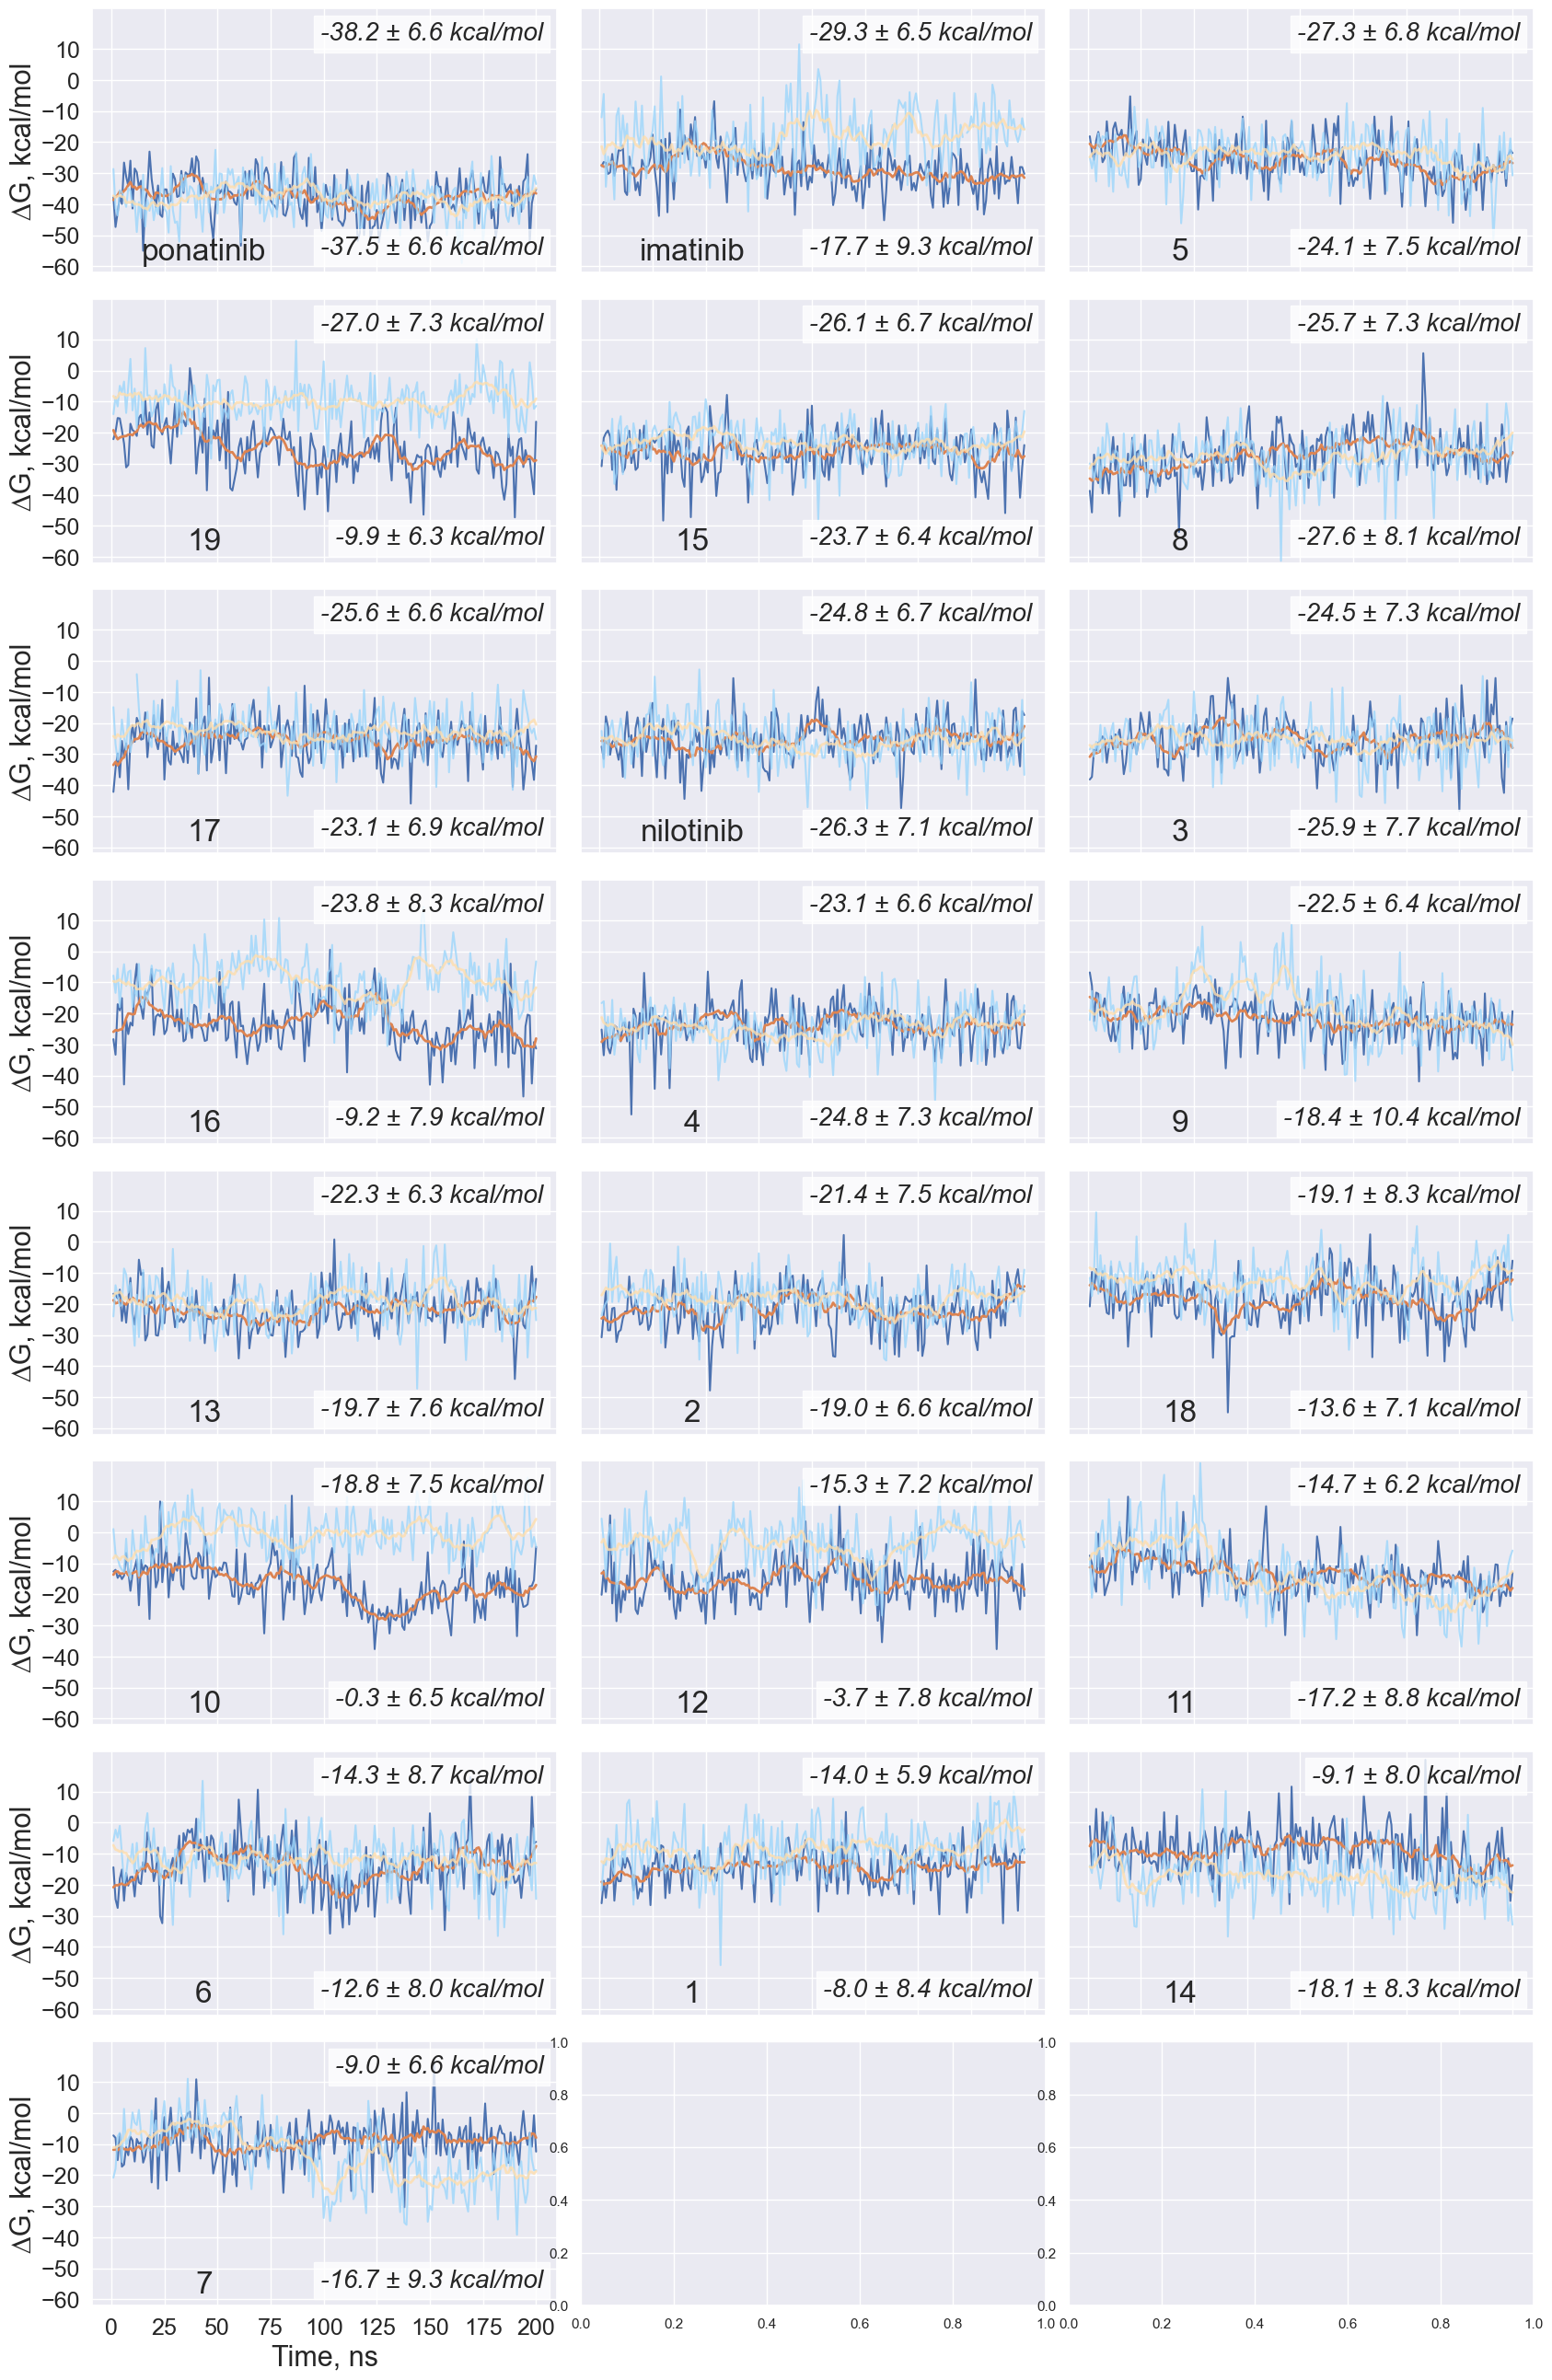

In [10]:
column = 'Energy' # Energy, Entropy, Enthalpy
n_cols = 3
n_rows = 8

show_without_smoothing = True

yticks = [10, 0, -10, -20, -30, -40, -50, -60]
xticks = [0, 25, 50, 75, 100, 125, 150, 175, 200]

#####

if RU:
    lang = "RU"
    time_label = 'Время, нс'
    energy_units = 'ккал/моль'
else:
    lang = "EN"
    time_label = 'Time, ns'
    energy_units = 'kcal/mol'

if column == 'Entropy' or column == 'Energy':
    time_arr = entropy_time
    window_size = 11           #windows_size entropy
else:
    time_arr = enthalpy_time
    window_size = 101          #windows_size enthalpy

ligands_energy = np.concatenate([df_energy[f"{column}_native"].values, df_energy[f"{column}_mutant"].values])
if not show_without_smoothing:
    ligands_energy = [mean_window(i, window_size=window_size) for i in ligands_energy]

energy_max = ligands_energy[0].max()
energy_min = ligands_energy[0].min()

for i in ligands_energy:
    if i.max() > energy_max:
        energy_max = i.max()
    if i.min() < energy_min:
        energy_min = i.min()    
        
print(f"Max energy: {energy_max:0.1f}\t Min energy: {energy_min:0.1f}")

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5*n_cols + 2, 3*n_rows + 2),  gridspec_kw=dict(width_ratios=n_cols*[1]))

i, j = 0, 0
for ligand_name, energy_n, mean_std_n, energy_m, mean_std_m in df_energy[['Name', f"{column}_native", f"{column}_mean_std_native", f"{column}_mutant", f"{column}_mean_std_mutant"]].values:
    # make skip
    # if (i==0 and j==1) or (i==0 and j==2):
    #     axs[i, j].set_yticklabels([])
    #     axs[i, j].set_xticklabels([])
    #     axs[i, j].set_facecolor('white')
    #     j += 1
    #     if j % n_cols == 0:
    #         j = 0
    #         i += 1
    if show_without_smoothing:
        axs[i, j].plot(time_arr, energy_n)
    axs[i, j].plot(time_arr, mean_window(energy_n, window_size=window_size), linewidth=2)
    
    if show_without_smoothing:
        axs[i, j].plot(time_arr, energy_m, color="#9dd6fb", alpha=0.8)
    axs[i, j].plot(time_arr, mean_window(energy_m, window_size=window_size), linewidth=2, color="navajowhite", alpha=0.8)

    axs[i, j].set_title(ligand_name, fontdict={'fontsize': 24}, x=0.24, y=0.02)
    
    axs[i, j].set_yticks(yticks)
    if j!=0:
        axs[i, j].set_yticklabels([])
    else:
        axs[i, j].set_ylabel('∆G, ' + energy_units, fontsize=22)
        
    axs[i, j].set_xticks(xticks)
    if i!=n_rows-1:
        axs[i, j].set_xticklabels([])
    else:
        axs[i, j].set_xlabel(time_label, fontsize=22)
        
    axs[i, j].set_ylim([math.floor(energy_min), math.ceil(energy_max)])
    axs[i, j].tick_params(axis='both', which='major', labelsize=18)
    axs[i, j].text(0.97, 0.95, f'{mean_std_n[0]:.1f} ± {mean_std_n[1]:.1f} ' + energy_units, style='italic', bbox={'facecolor': 'white', 'alpha': 0.8, 'pad': 5}, fontsize=20, horizontalalignment="right", verticalalignment='top', transform=axs[i, j].transAxes)
    axs[i, j].text(0.97, 0.05, f'{mean_std_m[0]:.1f} ± {mean_std_m[1]:.1f} ' + energy_units, style='italic', bbox={'facecolor': 'white', 'alpha': 0.8, 'pad': 5}, fontsize=20, horizontalalignment="right", verticalalignment='bottom', transform=axs[i, j].transAxes)
    
    j += 1
    if j % n_cols == 0:
        j = 0
        i += 1

# skip at the end
#axs[n_rows-1, n_cols-1].set_yticklabels([])
#axs[n_rows-1, n_cols-1].set_xticklabels([])
#axs[n_rows-1, n_cols-1].set_facecolor('white')        

fig.tight_layout(pad=1)
fig.subplots_adjust(wspace=0.05, hspace=0.1)
fig.savefig(save_dir + '/' + column + '_plots_' + lang + '.png', dpi=300)
plt.show()

# RMSD analysis

##### Helper Functions

In [11]:
def rmsd_dat_to_csv(dat_file):
    dat_content = open(dat_file).readlines()
    csv_content_list = [','.join(i.strip().split()) for i in dat_content]
    csv_content = '\n'.join(csv_content_list).strip()
    
    return StringIO(csv_content)

### Read order for data

In [12]:
rmsd_file_csv = save_dir + os.sep + "energy_top_order.csv"

#####

df_order = pd.read_csv(rmsd_file_csv, dtype={'Name' : str, 'New name' : str})

#### Add protein apo-form (optional)

In [13]:
df_apo = pd.DataFrame({'Name': ['apo'], 'New name': ['Abl1 kinase']})

#####

df_order = pd.concat([df_apo, df_order], ignore_index = True)

## RMSD backbone atoms (start structure as reference)

##### Helper Functions

In [14]:
def get_rmsd_df(rmsd_backbone_dir, rmsd_start, rmsd_end, rmsd_step):
    pd_rmsd_dict = {'Name' : [], 'rmsd' : []}
    
    for dat_file in glob.glob(rmsd_backbone_dir + os.sep + '*.dat'):
        pd_rmsd_dict['Name'].append(os.path.basename(dat_file)[:-4])
        pd_rmsd_dict['rmsd'].append(pd.read_csv(rmsd_dat_to_csv(dat_file), names=['frame', 'rmsd'], header=0)['rmsd'].values)
        
    df_rmsd = pd.DataFrame(pd_rmsd_dict)
    df_rmsd['rmsd_mean_std'] = df_rmsd['rmsd'].apply(lambda x: (x.mean(), x.std()))
    return df_rmsd

### Read RMSD data

In [15]:
rmsd_dir_native = work_dir_native + os.sep + 'rmsd_backbone_begin' 
rmsd_dir_mutant = work_dir_mutant + os.sep + 'rmsd_backbone_begin'
rmsd_start, rmsd_end, rmsd_step = 2, 4000, 2

#####

rmsd_time = np.arange(rmsd_start, rmsd_end+1, rmsd_step) / frames_per_ns

df_rmsd = pd.merge(get_rmsd_df(rmsd_dir_native, rmsd_start, rmsd_end, rmsd_step), 
                   get_rmsd_df(rmsd_dir_mutant, rmsd_start, rmsd_end, rmsd_step), 
                   on="Name", suffixes=("_native", "_mutant"))

print(f"RMSD data quantity: {df_rmsd.shape[0]}")
df_rmsd.head()

RMSD data quantity: 23


,Name,rmsd_native,rmsd_mean_std_native,rmsd_mutant,rmsd_mean_std_mutant
0,1,"[2.0051, 2.0393, 2.1486, 2.4531, 2.6895, 2.269...","(2.60701875, 0.4100176200645986)","[1.6378, 1.5956, 1.7482, 1.5701, 1.5641, 1.554...","(2.7773491000000003, 0.5586126207124128)"
1,10,"[1.489, 1.2893, 1.3561, 1.5074, 1.4484, 1.4733...","(3.1734899, 0.48897477109559545)","[2.0075, 2.0934, 1.8917, 1.9991, 2.0304, 2.072...","(2.2282473, 0.3299737532936673)"
2,11,"[1.9444, 2.1376, 1.9968, 1.901, 1.6805, 2.0795...","(2.5742223, 0.5123788332403183)","[1.6893, 1.8263, 1.5861, 1.6122, 1.6614, 1.519...","(2.6368087000000004, 0.5671660258022425)"
3,12,"[1.955, 2.0182, 1.9747, 1.8192, 1.9817, 2.0428...","(3.6849647, 0.7478502943463418)","[2.0046, 2.2274, 2.5013, 2.3222, 2.2609, 2.056...","(2.9171709, 0.48142802949474184)"
4,13,"[1.4932, 1.563, 1.8881, 1.7914, 1.9503, 2.1248...","(3.0161857, 0.42180022385663807)","[2.1481, 2.3408, 1.8783, 2.1467, 1.9961, 2.135...","(2.3778387000000003, 0.38781686429590706)"


### Set order for data

In [16]:
df_rmsd = pd.merge(df_order, df_rmsd, on='Name', how='left').drop(columns="Name").rename(columns={"New name" : "Name"})

### Draw plots

Enter the appropriate number of rows and columns for your data

Max RMSD: 6.0


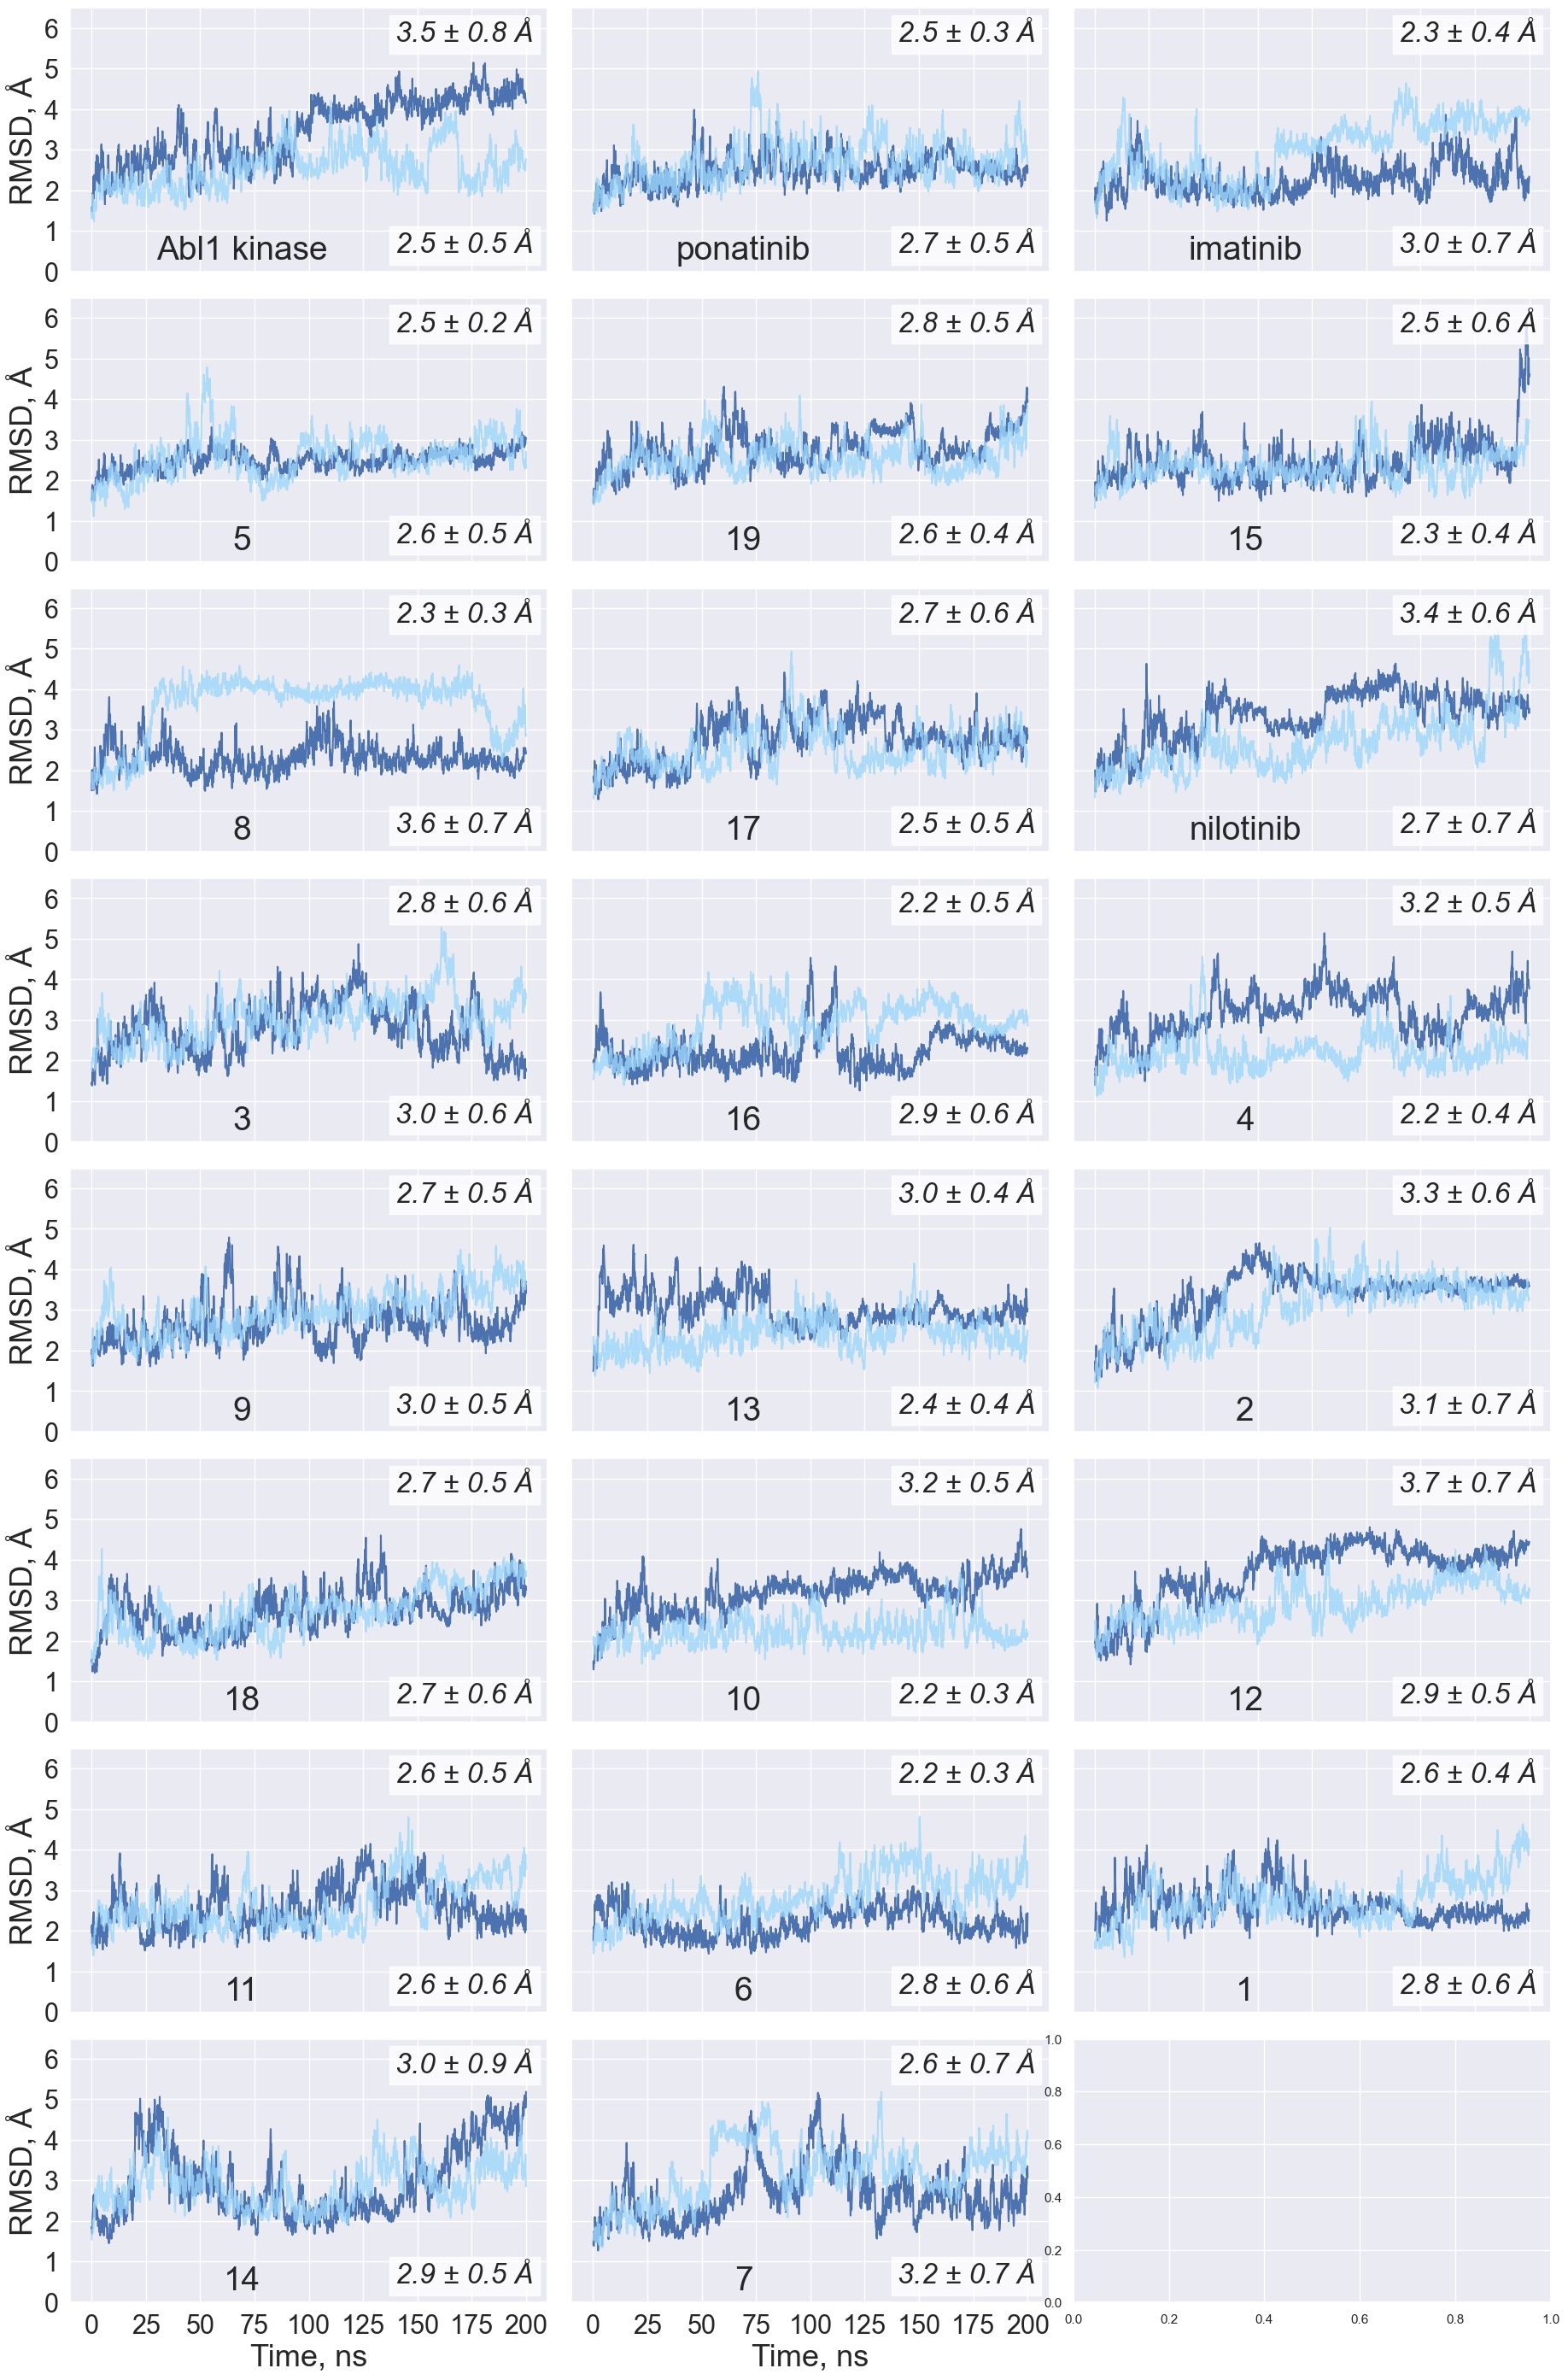

In [17]:
n_rows = 8
n_cols = 3
rmsd_max = 6

yticks = [0, 1, 2, 3, 4, 5, 6]
xticks = [0, 25, 50, 75, 100, 125, 150, 175, 200]

#####

if RU:
    lang = "RU"
    title = "Время, нс"
else:
    lang = "EN"
    title = "Time, ns"

rmsd_max = 0
ligands_rmsd = np.concatenate([df_rmsd["rmsd_native"].values, df_rmsd["rmsd_mutant"].values])
for i in ligands_rmsd:
    if i.max() > rmsd_max:
        rmsd_max = i.max()
        
print(f"Max RMSD: {rmsd_max:0.1f}")

fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(5.5*n_cols + 2, 3*n_rows + 4),  gridspec_kw=dict(width_ratios=[1]*n_cols))

i, j = 0, 0
for complex_name, rmsd_n, mean_std_n, rmsd_m, mean_std_m in df_rmsd[['Name', 'rmsd_native', 'rmsd_mean_std_native', 'rmsd_mutant', 'rmsd_mean_std_mutant']].values:
    # make skip
    # if (i==0 and j==1) or (i==0 and j==2):
    #     axs[i, j].set_yticklabels([])
    #     axs[i, j].set_xticklabels([])
    #     axs[i, j].set_facecolor('white')
    #     j += 1
    #     if j % n_cols == 0:
    #         j = 0
    #         i += 1
    axs[i, j].plot(rmsd_time, rmsd_n)
    axs[i, j].plot(rmsd_time, rmsd_m, color="#9dd6fb", alpha=0.8)
    axs[i, j].set_title(complex_name, fontdict={'fontsize': 28}, x=0.36, y=0.02)
        
    axs[i, j].set_yticks(yticks)
    
    if j == 0:
        axs[i, j].set_ylabel('RMSD, Å', fontsize=26)
    else:
        axs[i, j].set_yticklabels([])
        
    axs[i, j].set_xticks(xticks)
    
    if i == n_rows-1:
        axs[i, j].set_xlabel(title, fontsize=26)
    else:
        axs[i, j].set_xticklabels([])
        
    axs[i, j].set_ylim([0-0.01, rmsd_max + 0.5])
    axs[i, j].tick_params(axis='both', which='major', labelsize=22)
    axs[i, j].text(0.97, 0.95, f'{mean_std_n[0]:.1f} ± {mean_std_n[1]:.1f} Å', style='italic', bbox={'facecolor': 'white', 'alpha': 0.8, 'pad': 5}, fontsize=24, horizontalalignment="right", verticalalignment='top', transform=axs[i, j].transAxes)
    axs[i, j].text(0.97, 0.05, f'{mean_std_m[0]:.1f} ± {mean_std_m[1]:.1f} Å', style='italic', bbox={'facecolor': 'white', 'alpha': 0.8, 'pad': 5}, fontsize=24, horizontalalignment="right", verticalalignment='bottom', transform=axs[i, j].transAxes)
    
    j += 1
    if j % n_cols == 0:
        j = 0
        i += 1

# skip at the end
# axs[n_rows-1, n_cols-1].set_yticklabels([])
# axs[n_rows-1, n_cols-1].set_xticklabels([])
# axs[n_rows-1, n_cols-1].set_facecolor('white')

fig.tight_layout(pad=1)
fig.subplots_adjust(wspace=0.05, hspace=0.1)
fig.savefig(save_dir + os.sep + 'rmsd_' + lang + '.png', dpi=300)
plt.show()